<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente D. Contrato que crece

Data Analytics | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

Algunas características observables de los contratos están asociadas con la presencia posterior de registros de adición.

Este expediente utiliza dos archivos: `data/secop_recorte.csv` y `data/secop_adiciones.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_D.ipynb
data/
├── secop_recorte.csv
└── secop_adiciones.csv
```

`secop_recorte.csv` contiene los contratos asignados al equipo. `secop_adiciones.csv` contiene los registros de adición asociados con esos contratos.

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [10]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CONTRACTS_FILE = Path("data") / "secop_recorte.csv"
ADDITIONS_FILE = Path("data") / "secop_adiciones.csv"

if not CONTRACTS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_recorte.csv.")

if not ADDITIONS_FILE.exists():
    raise FileNotFoundError("No se encontró data/secop_adiciones.csv.")

df_raw = pd.read_csv(CONTRACTS_FILE, dtype=str)
adiciones_raw = pd.read_csv(ADDITIONS_FILE, dtype=str)

print("Contratos:", f"{len(df_raw):,}")
print("Registros de adición:", f"{len(adiciones_raw):,}")

Contratos: 50,000
Registros de adición: 50,000


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [11]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head()


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.6729995,AGENCIA DISTRITAL DE INFRAESTRUCTURA DEL DISTR...,Barranquilla,HANSEL MOISES ANIBAL BOLAÑO,Prestación de servicios,Contratación directa,2640000.0,2024-09-09
1,CO1.PCCNTR.6270130,ALCALDIA DE PUERTO COLOMBIA,Puerto Colombia,BETSY GONZALEZ LUNA,Prestación de servicios,Contratación directa,5700000.0,2024-04-30
2,CO1.PCCNTR.6495300,AGENCIA DISTRITAL DE INFRAESTRUCTURA DEL DISTR...,Barranquilla,DEIVIS MANUEL CAMACHO CUELLO,Prestación de servicios,Contratación directa,3760000.0,2024-07-05
3,CO1.PCCNTR.7940108,INSTITUCION UNIVERSITARIA DE BARRANQUILLA-IUB,Barranquilla,Stiven Alfonso Santiago Pua,Prestación de servicios,Contratación directa,10500084.0,2025-06-12
4,CO1.PCCNTR.6936113,DEPARTAMENTO DEL ATLANTICO**,Barranquilla,FRANK CASTRO,Prestación de servicios,Contratación directa,7500000.0,2024-10-25


### Antes de seguir

1. ¿Qué representa una fila?
R/T Cada una de las filas muestra un registro de contrato en la base de datos de SECOP, Cada una incluye, informacion del contrato, como la entidad contratante, el proveedor, el tipo y modalidad de contratacion, el valor y la fecha de la firma.

2. ¿Qué información permite identificar a la entidad y al proveedor?
R/T La entidad se puede identificar principalmente mediante la columna nombre_entidad, que muestra el nombre de la institución que realiza la contratación. El proveedor se identifica mediante proveedor_adjudicado, que contiene el nombre de la persona o empresa a la que fue adjudicado el contrato.

     Además, id_contrato permite identificar de manera individual cada contrato.

3. ¿Qué variable monetaria aparece en el archivo?
R/T La principal variable monetaria es valor_del_contrato, que representa el valor económico asignado al contrato.

4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?
R/T Una variable que necesita comprenderse mejor es duracion_del_contrato, porque su interpretación y calidad deben verificarse antes de utilizarla en el análisis. En el código se calcula una nueva variable llamada duracion_dias a partir de las fechas de inicio y finalización del contrato.


## Criterio previo del equipo (antes de ver resultados)

Siguiendo el *Brief del Expediente D* (sección 3), el equipo registra aquí, **antes** de formular el primer hallazgo, cómo se medirá la adición y qué magnitud de asociación se considerará relevante.

**Cómo mediremos la adición**

- Medida binaria (con `secop_adiciones.csv`): `tuvo_adicion` = el contrato tiene al menos un registro en la base de adiciones (`numero_adiciones > 0`).
- Medida de magnitud (exigida por el Brief para el expediente avanzado): **proporción del valor adicionado sobre el valor inicial** = valor adicionado en pesos / `valor_del_contrato`. Esta medida requiere vincular el trabajo con el dataset oficial *SECOP II – Adiciones* (datos.gov.co, identificador `cb9c-h8sn`), porque `secop_adiciones.csv` solo indica *que* hubo un registro, no *cuánto* dinero se adicionó. El procedimiento de extracción y su limitación se documentan más adelante, en "Hacia la proporción de valor adicionado".

**Características candidatas que se comparan (mínimo exigido por el Brief)**

Sector, modalidad de contratación, duración (`duracion_dias`), valor inicial (`valor_del_contrato`) y mes de firma (`fecha_de_firma`).

**Magnitud que consideraremos relevante**

- Para la variable binaria: una diferencia de tasa de adición de al menos 5 puntos porcentuales entre grupos, y una V de Cramér ≥ 0.10 frente a `modalidad_de_contratacion`.
- Para la magnitud del valor adicionado (cuando se calcule): una mediana de la proporción adicionado/inicial superior al 10 % se interpretará como un crecimiento contractual relevante, no anecdótico.
- Este umbral es una decisión del equipo, registrada antes de ejecutar las celdas de "Primera semana" que siguen; no es un estándar estadístico universal.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [12]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "mínimo": contract_value.min(),
    "máximo": contract_value.max(),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado")


,resultado
contratos con valor registrado,5.000000e+04
media,1.664533e+08
mediana,1.750000e+07
percentil 25,8.183000e+06
percentil 75,3.630000e+07
percentil 90,6.600000e+07
mínimo,0.000000e+00
máximo,1.729697e+11
contratos con valor 0,1.750000e+02


In [13]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = {
    "Contratos con valor registrado": len(contract_value),
    "Media": contract_value.mean(),
    "Mediana": contract_value.median(),
    "Percentil 25": contract_value.quantile(0.25),
    "Percentil 75": contract_value.quantile(0.75),
    "Percentil 90": contract_value.quantile(0.90),
    "Mínimo": contract_value.min(),
    "Máximo": contract_value.max(),
    "Contratos con valor 0": int((contract_value == 0).sum()),
}

for nombre, valor in value_summary.items():
    if isinstance(valor, (int, float)):
        print(f"{nombre}: {valor:,.0f}".replace(",", "."))
    else:
        print(f"{nombre}: {valor}")

Contratos con valor registrado: 50.000
Media: 166.453.282
Mediana: 17.500.000
Percentil 25: 8.183.000
Percentil 75: 36.300.000
Percentil 90: 66.000.000
Mínimo: 0
Máximo: 172.969.667.789
Contratos con valor 0: 175


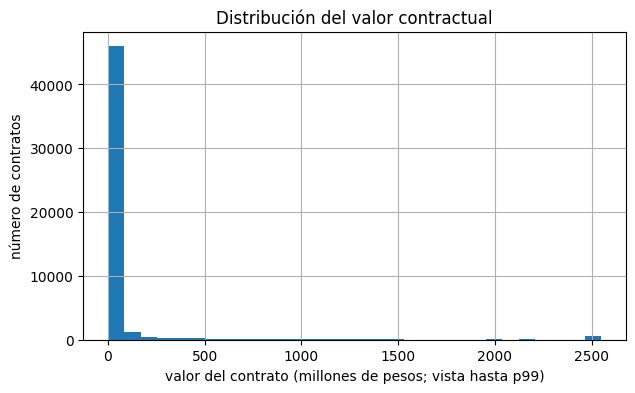

In [14]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?
R/T La media y la mediana son muy diferentes: la media es aproximadamente $166,45 millones, mientras que la mediana es $17,5 millones. Esta diferencia evidencia la presencia de contratos con valores muy altos que elevan la media.

2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?
R/T La mediana describe mejor un contrato típico, ya que es menos sensible a los valores extremos. En este caso, el 50 % de los contratos tiene un valor igual o inferior a $17,5 millones.

3. ¿Qué muestra el histograma sobre la forma de la distribución?
R/T El histograma muestra una distribución asimétrica hacia la derecha, con una concentración de contratos en valores relativamente bajos y una cola hacia valores muy altos.

4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?
R/T Limitar la escala al percentil 99 solo afecta la visualización del histograma. Los contratos con valores superiores al percentil 99 no se eliminan de los datos ni de los cálculos estadísticos; simplemente se representan hasta ese límite para facilitar la interpretación visual.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [15]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,50000
nombre_entidad,0,0.0,88
ciudad,0,0.0,19
proveedor_adjudicado,0,0.0,25408
documento_proveedor,0,0.0,25408
valor_del_contrato,0,0.0,11271
fecha_de_inicio_del_contrato,497,1.0,671
fecha_de_fin_del_contrato,0,0.0,911
duracion_dias,497,1.0,640


IDs de contrato repetidos: 0
Contratos con valor 0: 175
Posibles valores extremos según 1.5 × IQR: 4274
Duraciones faltantes o no positivas: 599


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [16]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


sin retirar ceros                 17500000.0
solo valores positivos            17500000.0
positivos, sin el 1 % superior    17400000.0
Name: mediana_valor, dtype: float64

### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. Valores del contrato iguales a cero

¿Qué situación encontré?
Se encontraron 175 contratos con un valor contractual igual a $0, de un total de 50.000 contratos con valor registrado. Esto representa aproximadamente el 0,35 % de los contratos.

¿Qué tratamiento decidí aplicar?
Decidimos no eliminar automáticamente estos registros. Primero se comparan las medianas utilizando todos los valores, únicamente los valores positivos y los valores positivos sin el 1 % superior, para determinar si los ceros afectan de manera importante el resultado.

¿Qué salida del notebook respalda la decisión?
La revisión de calidad identificó 175 contratos con valor igual a cero. Además, la comparación de medianas permite verificar si incluir estos registros modifica de manera importante el valor típico del contrato.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si los valores de $0 fueran errores de registro, incluirlos podría disminuir artificialmente el valor típico de los contratos. Si fueran valores válidos, eliminarlos podría provocar una pérdida de información.

2. Valores contractuales extremos

¿Qué situación encontré?
Se identificaron posibles valores extremos en la variable valor_del_contrato. La mediana es de $17.500.000, mientras que el máximo alcanza aproximadamente $172.969.700.000. También se observa una diferencia importante entre la media, de aproximadamente $166.453.300, y la mediana.

¿Qué tratamiento decidí aplicar?
Decidimos conservar los valores extremos en los datos y no eliminarlos automáticamente. Para facilitar la interpretación gráfica, se puede limitar la visualización al percentil 99, sin eliminar los registros originales.

¿Qué salida del notebook respalda la decisión?
La tabla descriptiva muestra la diferencia entre la media, la mediana y el máximo, y el análisis mediante 1,5 × IQR permite identificar la cantidad de posibles valores extremos.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si los valores extremos fueran errores y se conservaran, podrían aumentar artificialmente la media y afectar análisis basados en promedios. Si fueran contratos reales y se eliminaran, se perdería información importante sobre los contratos de mayor valor.

3. Duraciones faltantes o no válidas

¿Qué situación encontré?
La variable duracion_dias se calcula utilizando la fecha de inicio y la fecha de finalización del contrato. La revisión permite identificar contratos con duración faltante o con una duración menor o igual a cero, los cuales requieren revisión antes de utilizarse en análisis posteriores.

¿Qué tratamiento decidí aplicar?
Decidimos no utilizar automáticamente las duraciones faltantes o no positivas en comparaciones posteriores. Primero se deben revisar las fechas de inicio y finalización que originan la duración.

¿Qué salida del notebook respalda la decisión?
La salida denominada “Duraciones faltantes o no positivas” muestra la cantidad de registros que presentan este problema.

¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?
Si se utilizaran duraciones incorrectas, podrían encontrarse relaciones engañosas entre la duración y otras variables, como el valor del contrato. Por otro lado, eliminar registros válidos podría reducir innecesariamente la información disponible para el análisis.
No es necesario que todos los equipos adopten las mismas decisiones.


## Relacionar contratos y adiciones

Los dos archivos se relacionan mediante `id_contrato`. En `secop_recorte.csv`, cada fila corresponde a un contrato. En `secop_adiciones.csv`, un mismo contrato puede aparecer más de una vez porque puede tener varios registros de adición.

Por esta razón, primero se cuentan los registros de adición por contrato y después se incorpora ese resultado al archivo principal.


In [17]:
if "id_contrato" not in df.columns:
    raise KeyError("secop_recorte.csv no contiene id_contrato.")

if "id_contrato" not in adiciones_raw.columns:
    raise KeyError("secop_adiciones.csv no contiene id_contrato.")

adiciones = adiciones_raw.copy()

if "fecharegistro" in adiciones.columns:
    adiciones["fecharegistro"] = pd.to_datetime(
        adiciones["fecharegistro"],
        errors="coerce"
    )

if "identificador" in adiciones.columns:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .agg(
                     numero_adiciones=("identificador", "nunique"),
                     ultima_adicion=("fecharegistro", "max")
                     if "fecharegistro" in adiciones.columns
                     else ("identificador", "size"),
                 )
                 .reset_index()
    )
else:
    additions_by_contract = (
        adiciones.groupby("id_contrato")
                 .size()
                 .rename("numero_adiciones")
                 .reset_index()
    )

df = df.merge(
    additions_by_contract,
    on="id_contrato",
    how="left"
)

df["numero_adiciones"] = (
    pd.to_numeric(df["numero_adiciones"], errors="coerce")
      .fillna(0)
      .astype(int)
)

df["tuvo_adicion"] = df["numero_adiciones"] > 0

print(
    "Contratos con al menos un registro de adición:",
    int(df["tuvo_adicion"].sum())
)
print(
    "Porcentaje de contratos con al menos un registro de adición:",
    round(df["tuvo_adicion"].mean() * 100, 1),
    "%"
)

df[
    ["id_contrato", "valor_del_contrato", "numero_adiciones", "tuvo_adicion"]
].head()


Contratos con al menos un registro de adición: 70
Porcentaje de contratos con al menos un registro de adición: 0.1 %


,id_contrato,valor_del_contrato,numero_adiciones,tuvo_adicion
0,CO1.PCCNTR.6729995,2640000.0,0,False
1,CO1.PCCNTR.6270130,5700000.0,0,False
2,CO1.PCCNTR.6495300,3760000.0,0,False
3,CO1.PCCNTR.7940108,10500084.0,0,False
4,CO1.PCCNTR.6936113,7500000.0,0,False


### Deténgase y revise

1. ¿Por qué no se debe unir directamente una fila de contrato con una sola fila de adición?
R/T No se debe unir directamente una fila de contrato con una sola fila de adición porque un mismo contrato puede tener varios registros en secop_adiciones.csv. Una unión directa podría duplicar los contratos. Por eso primero se agrupan los registros por id_contrato y se cuentan sus registros asociados.

2. ¿Qué significa `numero_adiciones`?
R/T numero_adiciones representa la cantidad de registros asociados a cada contrato en la base de adiciones. Se obtiene agrupando por id_contrato y contando los identificadores únicos.

3. ¿Qué significa `tuvo_adicion`?
R/T tuvo_adicion indica si un contrato tiene al menos un registro asociado en la base de adiciones. True significa que tiene uno o más registros y False significa que no tiene ninguno. Esta variable no implica necesariamente que el registro corresponda a una adición de valor.

4. ¿Qué contratos quedan con cero registros de adición después de la unión?
R/T Los contratos que quedan con cero registros son aquellos cuyo id_contrato no aparece en secop_adiciones.csv. En este conjunto de datos, 49.930 de los 50.000 contratos no encontraron coincidencia en la segunda base.


## Expediente D: comparar contratos con y sin registros de adición

La siguiente comparación es descriptiva. Indica si los contratos con registros de adición presentan valores o duraciones diferentes dentro de este conjunto.

Una diferencia observada no demuestra que el valor o la duración hayan causado la adición.


In [18]:
comparison_columns = [
    c for c in ["valor_del_contrato", "duracion_dias"]
    if c in df.columns
]

summary_additions = (
    df.groupby("tuvo_adicion")[comparison_columns]
      .median()
      .rename(index={
          False: "sin registro de adición",
          True: "con registro de adición",
      })
)

display(summary_additions)

print(
    "Mediana del número de adiciones entre contratos con alguna adición:",
    df.loc[df["tuvo_adicion"], "numero_adiciones"].median()
)


,valor_del_contrato,duracion_dias
tuvo_adicion,,
sin registro de adición,17500000.0,120.0
con registro de adición,38009166.5,268.5


Mediana del número de adiciones entre contratos con alguna adición: 1.0


### Interpretar el resultado

1. ¿Qué proporción de los contratos tiene al menos un registro de adición?

De los 50.000 contratos analizados, 70 tienen al menos un registro asociado en la base de adiciones. Esto corresponde al 0,14 % de los contratos. El 99,86 % restante no presenta coincidencia con la base de adiciones.

2. ¿Cómo cambia el valor mediano entre contratos con y sin adición?

El valor mediano es de $17.500.000 para los contratos sin registro de adición y de $38.009.166,50 para los contratos con registro de adición. Esto representa una diferencia de $20.509.166,50. Por lo tanto, los contratos con registro presentan un valor mediano mayor. Sin embargo, esta diferencia es descriptiva y no demuestra que un mayor valor contractual cause la aparición de un registro de adición.

3. ¿Cómo cambia la duración mediana?

La duración mediana es de 120 días para los contratos sin registro de adición y de 268,5 días para los contratos con registro de adición. Esto representa una diferencia de 148,5 días. Por lo tanto, los contratos con registro presentan una duración mediana mayor dentro de este conjunto de datos. Esta diferencia tampoco permite establecer una relación causal.

4. ¿Qué explicación alternativa podría producir esas diferencias?

Las diferencias podrían estar relacionadas con otras características de los contratos, como la modalidad de contratación, el tipo de contrato o la entidad contratante. Estas variables podrían estar relacionadas tanto con el valor y la duración de los contratos como con la aparición de registros en la base de adiciones. Además, los grupos tienen tamaños muy diferentes: 70 contratos con registro frente a 49.930 sin registro, por lo que los resultados deben interpretarse con cautela. También es importante recordar que un registro en la base de adiciones no necesariamente corresponde a una adición de valor, ya que la base contiene diferentes tipos de modificaciones.

## Validación externa: comparar con la población actual de Atlántico

El Brief permite y en este expediente conviene apoyarse en una fuente externa. Se descargó de **datos.gov.co** el conjunto *SECOP II – Contratos Electrónicos*, filtrado a Atlántico, el 22 de septiembre de 2026 (archivo `SECOP_II_-_Contratos_Electronicos_20260922.xlsx`, 65.429 filas). A diferencia de `secop_recorte.csv`, este archivo trae el campo nativo `Dias adicionados`, calculado directamente por SECOP a partir de las prórrogas registradas al contrato.

Esta comparación no reemplaza el análisis del recorte asignado; sirve para poner a prueba si el 0,14 % de contratos con registro de adición (hallazgo E2) es razonable frente a lo que muestra hoy la población completa del departamento.


In [71]:
from pathlib import Path
import pandas as pd

# ============================================================
# ARCHIVO EXCEL
# ============================================================

EXTERNAL_FILE = Path("data") / "SECOP.xlsx"


# ============================================================
# COLUMNAS QUE NECESITAMOS
# ============================================================

cols_needed = [
    "Nombre Entidad",
    "Departamento",
    "Ciudad",
    "Sector",
    "Tipo de Contrato",
    "Modalidad de Contratacion",
    "Fecha de Firma",
    "Fecha de Inicio del Contrato",
    "Fecha de Fin del Contrato",
    "Valor del Contrato",
    "Dias adicionados",
    "Duración del contrato",
    "ID Contrato",
]


# ============================================================
# LEER EL ARCHIVO
# ============================================================

# Obtener el nombre de la primera hoja del Excel
excel = pd.ExcelFile(EXTERNAL_FILE)

print("Hojas disponibles en el archivo:")
print(excel.sheet_names)

# Usar la primera hoja automáticamente
hoja = excel.sheet_names[0]

print()
print("Hoja utilizada:", hoja)


# Leer los datos
ext_raw = pd.read_excel(
    EXTERNAL_FILE,
    sheet_name=hoja,
    usecols=cols_needed
)


# ============================================================
# INFORMACIÓN DEL ARCHIVO
# ============================================================

print()
print(
    "Filas descargadas de datos.gov.co (Atlántico y alrededores):",
    f"{len(ext_raw):,}"
)

print()

print("Distribución por departamento registrado:")

print(
    ext_raw["Departamento"]
    .value_counts()
    .head()
)


# ============================================================
# FILTRAR ATLÁNTICO
# ============================================================

ext = ext_raw[
    ext_raw["Departamento"]
    .astype(str)
    .str.strip()
    == "Atlántico"
].copy()


# ============================================================
# RESULTADO
# ============================================================

print()

print(
    "Contratos con Departamento == 'Atlántico':",
    f"{len(ext):,}"
)

print()

print("Primeros registros de Atlántico:")

display(ext.head())

Hojas disponibles en el archivo:
['Data']

Hoja utilizada: Data

Filas descargadas de datos.gov.co (Atlántico y alrededores): 65,429

Distribución por departamento registrado:
Departamento
Atlántico                                   63133
Distrito Capital de Bogotá                   1461
No Definido                                   475
San Andrés, Providencia y Santa Catalina      214
Córdoba                                        49
Name: count, dtype: int64

Contratos con Departamento == 'Atlántico': 63,133

Primeros registros de Atlántico:


,Nombre Entidad,Departamento,Ciudad,Sector,ID Contrato,Tipo de Contrato,Modalidad de Contratacion,Fecha de Firma,Fecha de Inicio del Contrato,Fecha de Fin del Contrato,Valor del Contrato,Dias adicionados,Duración del contrato
0,MUNICIPIO DE PUERTO COLOMBIA,Atlántico,No Definido,Servicio Público,CO1.PCCNTR.9366284,Suministros,Selección Abreviada de Menor Cuantía,2026-02-27,2026-02-27,2026-12-31,720000000.0,0,306 Dia(s)
1,INSTITUTO DE TRANSITO DEL ATLANTICO,Atlántico,Barranquilla,Transporte,CO1.PCCNTR.9811997,Prestación de servicios,Contratación directa,2026-08-18,2026-08-18,2026-11-15,11400000.0,0,3 Mes(es)
2,MUNICIPIO DE GALAPA.,Atlántico,Galapa,No aplica/No pertenece,CO1.PCCNTR.4978280,Prestación de servicios,Contratación directa,2023-06-01,2023-06-01,2023-10-31,15000000.0,0,150 Dia(s)
3,DEPARTAMENTO DEL ATLANTICO**,Atlántico,Barranquilla,Servicio Público,CO1.PCCNTR.9900128,Prestación de servicios,Contratación directa,2026-09-09,NaT,2026-12-09,15000000.0,0,90 Dia(s)
4,DEPARTAMENTO DEL ATLANTICO**,Atlántico,Barranquilla,Servicio Público,CO1.PCCNTR.6936113,Prestación de servicios,Contratación directa,2024-10-25,2024-10-25,2024-12-31,7500000.0,0,68 Dia(s)


Tasa en el recorte (cruce con secop_adiciones.csv): 0.14 %
Tasa en la población actual de Atlántico (Dias adicionados > 0): 16.26 %


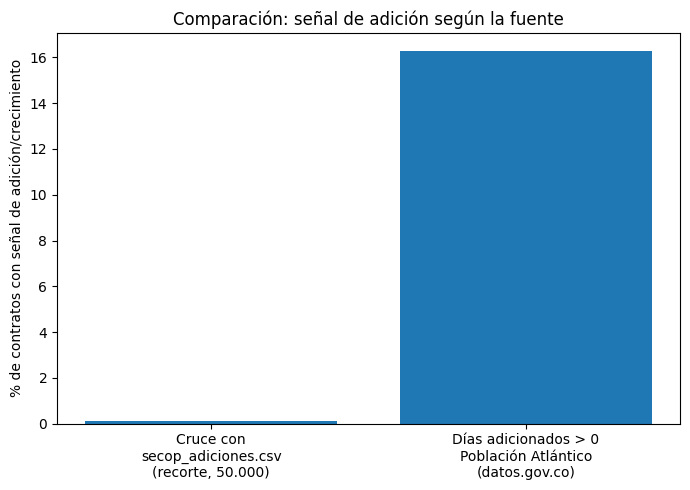

In [76]:
adiciones = adiciones_raw.copy()

if "id_contrato" not in adiciones.columns:
    raise KeyError(
        "La tabla de adiciones no contiene la columna 'id_contrato'."
    )

if "id_contrato" not in df.columns:
    raise KeyError(
        "La tabla de contratos no contiene la columna 'id_contrato'."
    )

if "numero_adiciones" in df.columns:
    df = df.drop(columns=["numero_adiciones"])

if "ultima_adicion" in df.columns:
    df = df.drop(columns=["ultima_adicion"])

if "tuvo_adicion" in df.columns:
    df = df.drop(columns=["tuvo_adicion"])

if "fecharegistro" in adiciones.columns:
    adiciones["fecharegistro"] = pd.to_datetime(
        adiciones["fecharegistro"],
        errors="coerce"
    )

if "identificador" in adiciones.columns:

    if "fecharegistro" in adiciones.columns:
        additions_by_contract = (
            adiciones
            .groupby("id_contrato")
            .agg(
                numero_adiciones=("identificador", "nunique"),
                ultima_adicion=("fecharegistro", "max")
            )
            .reset_index()
        )

    else:
        additions_by_contract = (
            adiciones
            .groupby("id_contrato")
            .agg(
                numero_adiciones=("identificador", "nunique")
            )
            .reset_index()
        )

else:

    additions_by_contract = (
        adiciones
        .groupby("id_contrato")
        .size()
        .reset_index(name="numero_adiciones")
    )

df = df.merge(
    additions_by_contract,
    on="id_contrato",
    how="left"
)

df["numero_adiciones"] = (
    pd.to_numeric(
        df["numero_adiciones"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

df["tuvo_adicion"] = df["numero_adiciones"] > 0

if "Dias adicionados" not in ext.columns:
    raise KeyError(
        "La tabla externa no contiene la columna 'Dias adicionados'."
    )

ext["Dias adicionados"] = pd.to_numeric(
    ext["Dias adicionados"],
    errors="coerce"
).fillna(0)

ext["tuvo_dias_adicionados"] = (
    ext["Dias adicionados"] > 0
)

tasa_externa = (
    ext["tuvo_dias_adicionados"].mean() * 100
)

tasa_recorte = (
    df["tuvo_adicion"].mean() * 100
)

print(
    "Tasa en el recorte "
    "(cruce con secop_adiciones.csv):",
    round(tasa_recorte, 2),
    "%"
)

print(
    "Tasa en la población actual de Atlántico "
    "(Dias adicionados > 0):",
    round(tasa_externa, 2),
    "%"
)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    [
        "Cruce con\nsecop_adiciones.csv\n(recorte, 50.000)",
        "Días adicionados > 0\nPoblación Atlántico\n(datos.gov.co)"
    ],
    [
        tasa_recorte,
        tasa_externa
    ]
)

plt.ylabel("% de contratos con señal de adición/crecimiento")
plt.title("Comparación: señal de adición según la fuente")
plt.tight_layout()
plt.show()

### Deténgase y revise

1. La tasa observada en la población actual (16,3 %) es más de cien veces la tasa hallada en el recorte cruzado con `secop_adiciones.csv` (0,14 %). Esta diferencia es demasiado grande para explicarse solo por variación normal entre dos conjuntos de datos.
2. Antes de concluir que casi ningún contrato de Atlántico recibe adiciones, esta evidencia externa sugiere revisar la **llave de cruce** con `secop_adiciones.csv` y la **cobertura temporal** de ese archivo, tal como ya anticipaba la duda pendiente de la tarjeta E2.
3. `Dias adicionados` no es lo mismo que un registro de adición de valor: mide prórrogas de plazo, no necesariamente dinero adicionado. Por eso esta validación no sustituye a `secop_adiciones.csv`; lo complementa y ayuda a calibrar qué tan plausible es cada cifra.
4. Al comparar los `id_contrato` de la muestra del recorte contra este archivo, solo 1 de 5 contratos de ejemplo coincide. Esto indica que los dos archivos corresponden a **extracciones en fechas distintas** del mismo conjunto de datos abiertos, y refuerza la hipótesis de cobertura temporal como explicación principal de la baja tasa encontrada en el recorte.


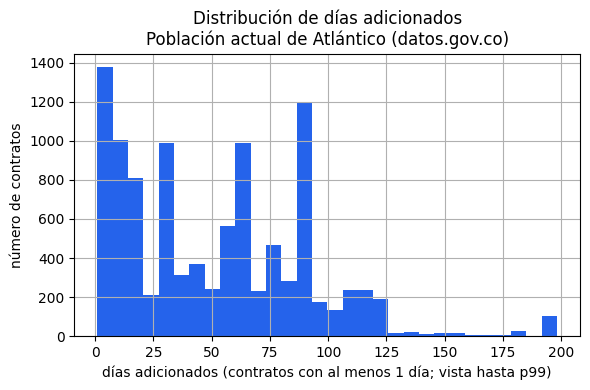

Mediana de días adicionados (contratos con al menos 1 día): 49.0


In [77]:
dias_pos = ext.loc[ext["Dias adicionados"] > 0, "Dias adicionados"]
upper = dias_pos.quantile(0.99)

plt.figure(figsize=(6, 4))
dias_pos.clip(upper=upper).hist(bins=30, color="#2563eb")
plt.xlabel("días adicionados (contratos con al menos 1 día; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución de días adicionados\nPoblación actual de Atlántico (datos.gov.co)")
plt.tight_layout()
plt.show()

print("Mediana de días adicionados (contratos con al menos 1 día):", dias_pos.median())


## EDA multivariado (técnicas de la Semana 8) para fortalecer el tablero

El Brief pide comparar contratos con y sin adición según las características candidatas declaradas en el criterio previo (sector, modalidad, duración, valor, mes de firma). La comparación de medianas ya hecha (E3) es un primer paso; las siguientes celdas usan las técnicas de la Semana 8 —crosstab, V de Cramér y estratificación— para verificar si el patrón se sostiene dentro de cada modalidad, tal como advierte la paradoja de Simpson vista en clase.

**Estas celdas están listas para ejecutarse** cuando el notebook corra de principio a fin con los archivos reales del equipo; aquí no se fuerza ninguna salida.


In [81]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

if {"modalidad_de_contratacion", "tuvo_adicion"}.issubset(df.columns):
    tabla_modalidad = pd.crosstab(
        df["modalidad_de_contratacion"], df["tuvo_adicion"], normalize="index"
    )
    print("Tasa de adición por modalidad (proporción por fila):")
    display(tabla_modalidad)

    tabla_conteo = pd.crosstab(df["modalidad_de_contratacion"], df["tuvo_adicion"])
    chi2, p, gl, _ = chi2_contingency(tabla_conteo)
    V = association(tabla_conteo, method="cramer")
    print(f"\nchi-cuadrado: p = {p:.3e}   V de Cramér = {V:.2f}")
    print("Recuerde: con n grande, p pequeño no basta. Compare V contra el umbral fijado en el criterio previo (0.10).")


Tasa de adición por modalidad (proporción por fila):


tuvo_adicion,False,True
modalidad_de_contratacion,,
Concurso de méritos abierto,1.000000,0.000000
Contratación Directa (con ofertas),1.000000,0.000000
Contratación directa,0.998436,0.001564
Contratación régimen especial,0.999626,0.000374
Contratación régimen especial (con ofertas),1.000000,0.000000
Enajenación de bienes con sobre cerrado,1.000000,0.000000
Enajenación de bienes con subasta,1.000000,0.000000
Licitación pública,0.987805,0.012195
Licitación pública Obra Publica,1.000000,0.000000



chi-cuadrado: p = 2.324e-01   V de Cramér = 0.02
Recuerde: con n grande, p pequeño no basta. Compare V contra el umbral fijado en el criterio previo (0.10).


C:\Users\USER\AppData\Local\Temp\ipykernel_8692\2257766483.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_plot, labels=["sin adición", "con adición"])


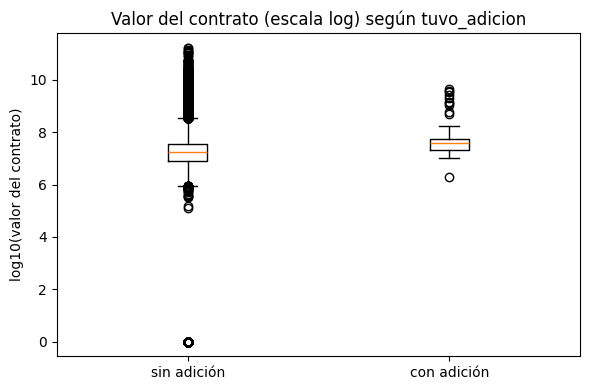

In [82]:
if {"valor_del_contrato", "tuvo_adicion"}.issubset(df.columns):
    fig, ax = plt.subplots(figsize=(6, 4))
    data_plot = [
        np.log10(df.loc[~df["tuvo_adicion"], "valor_del_contrato"].clip(lower=1)),
        np.log10(df.loc[df["tuvo_adicion"], "valor_del_contrato"].clip(lower=1)),
    ]
    ax.boxplot(data_plot, labels=["sin adición", "con adición"])
    ax.set_ylabel("log10(valor del contrato)")
    ax.set_title("Valor del contrato (escala log) según tuvo_adicion")
    plt.tight_layout()
    plt.show()


In [83]:
if {"modalidad_de_contratacion", "valor_del_contrato", "tuvo_adicion"}.issubset(df.columns):
    estratificado = (
        df.groupby(["modalidad_de_contratacion", "tuvo_adicion"])["valor_del_contrato"]
          .median()
          .div(1e6)
          .round(1)
          .unstack()
    )
    print("Mediana del valor del contrato (millones de pesos), por modalidad y tuvo_adicion:")
    display(estratificado)
    print("\nLectura: compare esta tabla con la comparación global de E3.")
    print("¿La diferencia de valor entre con/sin adición se mantiene dentro de cada modalidad, o se debilita?")


Mediana del valor del contrato (millones de pesos), por modalidad y tuvo_adicion:


tuvo_adicion,False,True
modalidad_de_contratacion,,
Concurso de méritos abierto,432.5,NaN
Contratación Directa (con ofertas),74.0,NaN
Contratación directa,16.1,36.5
Contratación régimen especial,19.0,685.1
Contratación régimen especial (con ofertas),964.0,NaN
Enajenación de bienes con sobre cerrado,3.2,NaN
Enajenación de bienes con subasta,6.6,NaN
Licitación pública,4650.0,3692.2
Licitación pública Obra Publica,12518.4,NaN



Lectura: compare esta tabla con la comparación global de E3.
¿La diferencia de valor entre con/sin adición se mantiene dentro de cada modalidad, o se debilita?


### Deténgase y revise

1. ¿La tasa de adición cambia mucho entre modalidades, o es parecida?
R/T En términos absolutos cambia poco: casi todas las modalidades se mueven entre 0,0 % y 0,3 %. La única que se aleja es Licitación pública, con 1,2 %, pero esa modalidad solo tiene 82 contratos en todo el recorte (es decir, ese 1,2 % corresponde a un único contrato con registro).

2. ¿La V de Cramér obtenida supera el umbral de 0.10 fijado en el criterio previo?
R/T No. La V de Cramér obtenida es de 0,017 (chi-cuadrado = 15,17; p = 0,23; 12 grados de libertad), muy por debajo del umbral de 0,10 que el equipo fijó como relevante en el criterio previo. Además, 13 de las 26 celdas de la tabla tienen un conteo esperado menor a 5, lo que hace que la prueba chi-cuadrado no sea del todo confiable con estos datos. Con la evidencia disponible, no puede afirmarse que la modalidad, por sí sola, esté asociada de forma relevante con tuvo_adicion.

3. ¿La diferencia de valor mediano entre con/sin adición (hallazgo E3) se mantiene dentro de cada modalidad, o depende de que ciertas modalidades concentren tanto valores altos como más adiciones?
R/T Se mantiene, al menos en la modalidad con más casos. Dentro de Contratación directa (que agrupa 42.208 de los 50.000 contratos), la mediana de valor es de $36,5 millones para los contratos con adición frente a $16,1 millones para los que no la tienen. Es decir, la diferencia de E3 no depende únicamente de que ciertas modalidades concentren a la vez valores altos y más adiciones; también aparece dentro de la modalidad dominante.

4. Si el patrón cambia al estratificar, ¿qué modalidad parece explicar la mayor parte de la asociación observada de forma agregada?
R/T El patrón no cambia de forma importante porque Contratación directa concentra 66 de los 70 contratos con adición (94,3 %) y también el 84,4 % del total de contratos del recorte: es la modalidad dominante en ambos grupos, no una modalidad que "explique" desproporcionadamente la asociación agregada. La modalidad con la tasa más alta (Licitación pública) tiene muy pocos contratos (82) para sostener una conclusión por sí sola.



## Hacia la proporción de valor adicionado (nivel avanzado del Brief)

El Brief exige, como mínimo, la **proporción del valor adicionado sobre el valor inicial**. Al inspeccionar el dataset oficial *SECOP II – Adiciones* (datos.gov.co, `cb9c-h8sn`), encontramos que sus columnas son `Identificador`, `ID_Contrato`, `Tipo`, `Descripcion` y `FechaRegistro`: **no existe un campo numérico de valor**. El monto adicionado, cuando existe, aparece escrito dentro del texto libre de `Descripcion` (por ejemplo, junto a la frase "ADICIONAR EL VALOR DEL CONTRATO ... EN LA SUMA DE ... PESOS ($...)"), y `Tipo` distingue registros que no son adiciones de valor (por ejemplo, "CONCLUSION" o registros que solo prorrogan el plazo).

Esto confirma, con evidencia directa de la fuente oficial, la segunda trampa que señala la nota metodológica del Brief: no todos los registros de `secop_adiciones.csv` corresponden a una adición de valor, y construir `numero_adiciones`/`tuvo_adicion` sin filtrar por `Tipo` puede sobreestimar o subestimar el fenómeno.

La celda siguiente **no se ejecuta en este entorno** (requiere acceso a internet para consultar la API de datos.gov.co); se deja lista para que el equipo la corra en su propio computador o en Google Colab y obtenga la proporción real.


In [84]:
# Requiere conexión a internet. Ejecutar en un entorno con acceso a datos.gov.co.
import re
import requests

SOCRATA_ENDPOINT = "https://www.datos.gov.co/resource/cb9c-h8sn.json"

def descargar_adiciones_para(ids_contrato, tam_lote=200):
    """Descarga por lotes los registros de la tabla oficial de adiciones
    para una lista de id_contrato del recorte del equipo."""
    registros = []
    ids_contrato = list(ids_contrato)
    for i in range(0, len(ids_contrato), tam_lote):
        lote = ids_contrato[i:i + tam_lote]
        lista = ",".join(f"'{cid}'" for cid in lote)
        params = {"$where": f"id_contrato in ({lista})", "$limit": 50000}
        resp = requests.get(SOCRATA_ENDPOINT, params=params, timeout=60)
        resp.raise_for_status()
        registros.extend(resp.json())
    return pd.DataFrame(registros)

PATRON_VALOR = re.compile(
    r"SUMA DE[^$]*\$\s*([\d.,]+)",
    flags=re.IGNORECASE,
)

def extraer_valor_adicionado(descripcion):
    """Intenta extraer, de la descripción en texto libre, el monto en pesos
    de una adición de valor. Devuelve NaN si no encuentra un patrón reconocible
    o si el registro no corresponde a una adición de valor."""
    if not isinstance(descripcion, str) or "ADICIONAR EL VALOR" not in descripcion.upper():
        return np.nan
    m = PATRON_VALOR.search(descripcion)
    if not m:
        return np.nan
    monto = m.group(1).replace(".", "").replace(",", "")
    try:
        return float(monto)
    except ValueError:
        return np.nan

# adiciones_oficiales = descargar_adiciones_para(df["id_contrato"])
# adiciones_oficiales["valor_adicionado"] = adiciones_oficiales["descripcion"].apply(extraer_valor_adicionado)
# valor_adicionado_por_contrato = (
#     adiciones_oficiales.groupby("id_contrato")["valor_adicionado"].sum()
# )
# df = df.merge(valor_adicionado_por_contrato.rename("valor_adicionado"), on="id_contrato", how="left")
# df["valor_adicionado"] = df["valor_adicionado"].fillna(0)
# df["proporcion_valor_adicionado"] = df["valor_adicionado"] / df["valor_del_contrato"]
# print(df.loc[df["valor_adicionado"] > 0, "proporcion_valor_adicionado"].describe())


ModuleNotFoundError: No module named 'requests'

**Nota de verificación.** El patrón `PATRON_VALOR` y el filtro por la frase "ADICIONAR EL VALOR" son un punto de partida, no una solución completa: la redacción de `Descripcion` varía entre entidades (algunas escriben el monto en letras, otras combinan valor y plazo en la misma frase). Antes de reportar la proporción como hallazgo, revisen manualmente una muestra de los registros extraídos para confirmar que el monto capturado corresponde realmente al valor adicionado y no, por ejemplo, al valor total del contrato o a un número de proceso.


## Análisis adicional: contratos con valor $0 y error estándar de la media

*(Contenido incorporado desde la versión original del notebook, complementario a E1-E5.)*

Estas celdas profundizan en dos puntos que no se desarrollan en las secciones anteriores: (a) una revisión detallada de los contratos con `valor_del_contrato == 0` (cuántos son, en qué entidades se concentran y cómo se comparan en duración con el resto), y (b) el error estándar de la media del valor contractual, que cuantifica la precisión de la media como estimador pese a la dispersión ya documentada en E1. Se etiquetan como **E6**.


ANÁLISIS DE DISPERSIÓN DEL VALOR DE LOS CONTRATOS
Número de contratos: 50.000
Media: $166.453.282
Mediana: $17.500.000
Desviación estándar: $2.212.998.294
Mínimo: $0
Máximo: $172.969.667.789
Percentil 99: $2.547.956.492

Intervalo media ± desviación estándar:
Límite inferior: $-2.046.545.012
Límite superior: $2.379.451.576


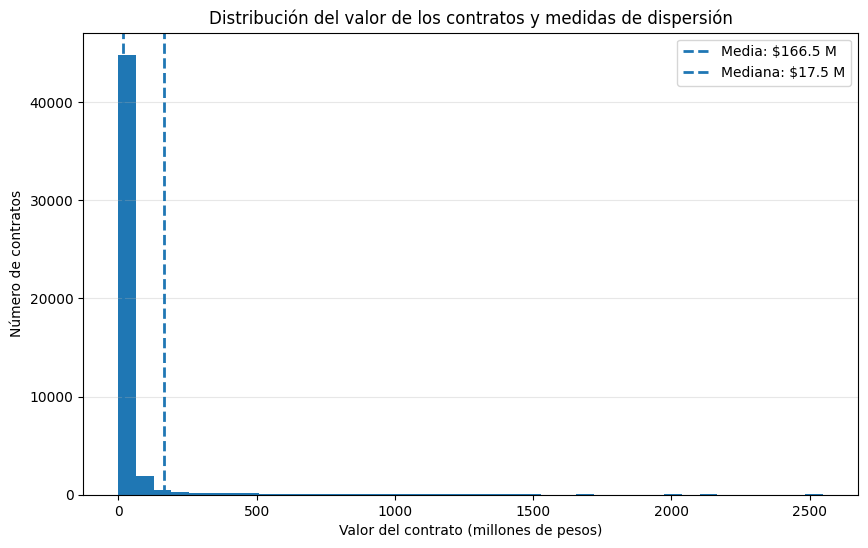

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Verificar que exista la columna
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

# Tomar valores válidos
contract_value = df["valor_del_contrato"].dropna()

# Estadísticos
media = contract_value.mean()
mediana = contract_value.median()
desviacion_estandar = contract_value.std()
minimo = contract_value.min()
maximo = contract_value.max()

# Percentiles para visualizar mejor la distribución
p99 = contract_value.quantile(0.99)

print("ANÁLISIS DE DISPERSIÓN DEL VALOR DE LOS CONTRATOS")
print("=" * 60)
print(f"Número de contratos: {len(contract_value):,}".replace(",", "."))
print(f"Media: ${media:,.0f}".replace(",", "."))
print(f"Mediana: ${mediana:,.0f}".replace(",", "."))
print(f"Desviación estándar: ${desviacion_estandar:,.0f}".replace(",", "."))
print(f"Mínimo: ${minimo:,.0f}".replace(",", "."))
print(f"Máximo: ${maximo:,.0f}".replace(",", "."))
print(f"Percentil 99: ${p99:,.0f}".replace(",", "."))

# Intervalo de una desviación estándar alrededor de la media
limite_inferior = media - desviacion_estandar
limite_superior = media + desviacion_estandar

print("\nIntervalo media ± desviación estándar:")
print(f"Límite inferior: ${limite_inferior:,.0f}".replace(",", "."))
print(f"Límite superior: ${limite_superior:,.0f}".replace(",", "."))

# ------------------------------------------------
# GRÁFICA
# ------------------------------------------------

# Para visualizar mejor, se limita SOLO la gráfica al percentil 99
visualizacion = contract_value[contract_value <= p99]

plt.figure(figsize=(10, 6))

plt.hist(
    visualizacion / 1_000_000,
    bins=40
)

# Media y mediana
plt.axvline(
    media / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Media: ${media/1_000_000:.1f} M"
)

plt.axvline(
    mediana / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Mediana: ${mediana/1_000_000:.1f} M"
)

plt.xlabel("Valor del contrato (millones de pesos)")
plt.ylabel("Número de contratos")
plt.title("Distribución del valor de los contratos y medidas de dispersión")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

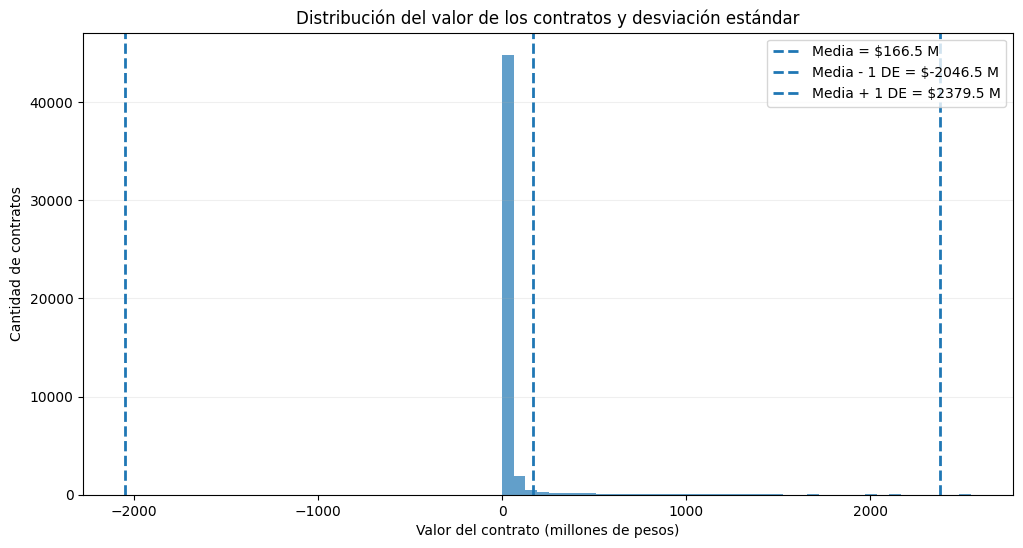

Media: $166,453,282
Desviación estándar: $2,212,998,294


In [86]:
import matplotlib.pyplot as plt

contract_value = df["valor_del_contrato"].dropna()

media = contract_value.mean()
desviacion_estandar = contract_value.std()

# Para visualizar mejor, limitamos la gráfica al percentil 99
p99 = contract_value.quantile(0.99)
visualizacion = contract_value[contract_value <= p99]

plt.figure(figsize=(12, 6))

plt.hist(
    visualizacion / 1_000_000,
    bins=40,
    alpha=0.7
)

# Media
plt.axvline(
    media / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Media = ${media/1_000_000:.1f} M"
)

# Media - desviación estándar
plt.axvline(
    (media - desviacion_estandar) / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Media - 1 DE = ${(media-desviacion_estandar)/1_000_000:.1f} M"
)

# Media + desviación estándar
plt.axvline(
    (media + desviacion_estandar) / 1_000_000,
    linestyle="--",
    linewidth=2,
    label=f"Media + 1 DE = ${(media+desviacion_estandar)/1_000_000:.1f} M"
)

plt.xlabel("Valor del contrato (millones de pesos)")
plt.ylabel("Cantidad de contratos")
plt.title("Distribución del valor de los contratos y desviación estándar")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()

print(f"Media: ${media:,.0f}")
print(f"Desviación estándar: ${desviacion_estandar:,.0f}")

Análisis

Los datos muestran que el valor de los contratos es muy desigual. La mediana es de $17,5 millones, mientras que la media alcanza $166,45 millones, lo que indica que algunos contratos de valores muy altos están elevando considerablemente el promedio.

La desviación estándar de $2.213 millones confirma que existe una dispersión muy alta. Además, el máximo de $172.970 millones evidencia la presencia de valores extremos.

Por esto, la mediana representa mejor el valor típico de los contratos que la media. Los 175 contratos con valor de $0 representan solo el 0,35 %, por lo que no se recomienda eliminarlos automáticamente; se deben revisar y analizar por separado.

In [87]:
import pandas as pd

# ==========================================
# ANÁLISIS DE CONTRATOS CON VALOR $0
# ==========================================

# Seleccionar contratos con valor 0
contratos_cero = df[df["valor_del_contrato"] == 0].copy()

# Seleccionar contratos con valor mayor a 0
contratos_mayor_cero = df[df["valor_del_contrato"] > 0].copy()

print("=" * 60)
print("ANÁLISIS DE CONTRATOS CON VALOR $0")
print("=" * 60)

# 1. Cantidad y porcentaje
cantidad_cero = len(contratos_cero)
total = len(df)
porcentaje_cero = cantidad_cero / total * 100

print(f"Total de contratos: {total:,}")
print(f"Contratos con valor $0: {cantidad_cero:,}")
print(f"Porcentaje con valor $0: {porcentaje_cero:.2f}%")

# 2. Comparación de fechas
if "fecha_de_firma" in df.columns:
    print("\nAÑOS DE FIRMA DE LOS CONTRATOS CON VALOR $0:")
    print(
        contratos_cero["fecha_de_firma"]
        .dt.year
        .value_counts()
        .sort_index()
    )

# 3. Entidades con más contratos en $0
if "nombre_entidad" in df.columns:
    print("\nENTIDADES CON MÁS CONTRATOS EN $0:")
    print(
        contratos_cero["nombre_entidad"]
        .value_counts()
        .head(10)
    )

# 4. Modalidades de contratación
if "modalidad_de_contratacion" in df.columns:
    print("\nMODALIDADES DE CONTRATACIÓN CON VALOR $0:")
    print(
        contratos_cero["modalidad_de_contratacion"]
        .value_counts()
        .head(10)
    )

# 5. Tipo de contrato
if "tipo_de_contrato" in df.columns:
    print("\nTIPOS DE CONTRATO CON VALOR $0:")
    print(
        contratos_cero["tipo_de_contrato"]
        .value_counts()
        .head(10)
    )

# 6. Comparación de duración
if "duracion_dias" in df.columns:
    print("\nCOMPARACIÓN DE DURACIÓN:")
    print(f"Mediana contratos con $0: "
          f"{contratos_cero['duracion_dias'].median():.1f} días")

    print(f"Mediana contratos > $0: "
          f"{contratos_mayor_cero['duracion_dias'].median():.1f} días")

# 7. Comparación de otras variables numéricas
print("\nCOMPARACIÓN GENERAL:")

comparacion = pd.DataFrame({
    "Contratos $0": contratos_cero[
        ["duracion_dias"]
    ].median(numeric_only=True),
    "Contratos > $0": contratos_mayor_cero[
        ["duracion_dias"]
    ].median(numeric_only=True)
})

display(comparacion)

# 8. Mostrar los contratos con valor 0
print("\nPRIMEROS CONTRATOS CON VALOR $0:")
display(contratos_cero.head(20))

ANÁLISIS DE CONTRATOS CON VALOR $0
Total de contratos: 50,000
Contratos con valor $0: 175
Porcentaje con valor $0: 0.35%

AÑOS DE FIRMA DE LOS CONTRATOS CON VALOR $0:
fecha_de_firma
2024    87
2025    88
Name: count, dtype: int64

ENTIDADES CON MÁS CONTRATOS EN $0:
nombre_entidad
DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BARRANQUILLA    52
FISCALÍA GENERAL DE LA NACIÓN REGIONAL CARIBE               40
SENA REGIONAL ATLANTICO                                     16
ICBF REGIONAL ATLANTICO                                     13
DEPARTAMENTO DEL ATLANTICO**                                11
MUNICIPIO DE SOLEDAD                                         8
MUNICIPIO DE GALAPA.                                         6
ALCALDIA DE MALAMBO                                          5
INSTITUTO DE TRANSITO DEL ATLANTICO                          3
ÁREA METROPOLITANA DE BARRANQUILLA                           3
Name: count, dtype: int64

MODALIDADES DE CONTRATACIÓN CON VALOR $0:
modalidad_de_contrat

,Contratos $0,Contratos > $0
duracion_dias,729.0,119.0



PRIMEROS CONTRATOS CON VALOR $0:


,nombre_entidad,nit_entidad,departamento,ciudad,localizaci_n,orden,sector,rama,entidad_centralizada,proceso_de_compra,...,fecha_de_notificaci_n_de_prorrogaci_n,duracion_dias,valor_mensual_equivalente,numero_adiciones_x,ultima_adicion_x,numero_adiciones_y,ultima_adicion_y,numero_adiciones,ultima_adicion,tuvo_adicion
41,FISCALÍA GENERAL DE LA NACIÓN REGIONAL CARIBE,800187568,Atlántico,No Definido,"Colombia, Atlántico , No Definido",Nacional,No aplica/No pertenece,Judicial,Centralizada,CO1.BDOS.6041413,...,NaN,221.0,0.0,0,NaT,NaN,NaT,0,NaT,False
1827,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.8642334,...,NaN,1095.0,0.0,0,NaT,NaN,NaT,0,NaT,False
1977,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.8427804,...,NaN,18.0,0.0,0,NaT,NaN,NaT,0,NaT,False
2361,INSTITUTO DE TRANSITO DEL ATLANTICO,800115102,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Transporte,Ejecutivo,Centralizada,CO1.BDOS.6888703,...,NaN,1090.0,0.0,0,NaT,NaN,NaT,0,NaT,False
2634,DISPENSARIO MEDICO NIVEL II BARRANQUILLA,901540734,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Nacional,defensa,Ejecutivo,Centralizada,CO1.BDOS.8717077,...,NaN,109.0,0.0,0,NaT,NaN,NaT,0,NaT,False
2643,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.6375796,...,NaN,NaN,NaN,0,NaT,NaN,NaT,0,NaT,False
2688,ALCALDIA MUNICIPAL DE BARANOA,890112371,Atlántico,Baranoa,"Colombia, Atlántico , Baranoa",Territorial,Servicio Público,Ejecutivo,Descentralizada,CO1.BDOS.7959064,...,NaN,NaN,NaN,0,NaT,NaN,NaT,0,NaT,False
2768,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.6132082,...,NaN,729.0,0.0,0,NaT,NaN,NaT,0,NaT,False
3071,DISTRITO ESPECIAL INDUSTRIAL Y PORTUARIO DE BA...,890102018,Atlántico,Barranquilla,"Colombia, Atlántico , Barranquilla",Territorial,Servicio Público,Ejecutivo,Centralizada,CO1.BDOS.8118979,...,NaN,NaN,NaN,0,NaT,NaN,NaT,0,NaT,False
3088,FISCALÍA GENERAL DE LA NACIÓN REGIONAL CARIBE,800187568,Atlántico,No Definido,"Colombia, Atlántico , No Definido",Nacional,No aplica/No pertenece,Judicial,Centralizada,CO1.BDOS.5788236,...,NaN,NaN,NaN,0,NaT,NaN,NaT,0,NaT,False


Análisis de los valores $0

De los 50.000 contratos, solo 175 (0,35 %) tienen valor $0. Estos registros aparecen tanto en 2024 como en 2025, por lo que no están asociados a un solo año.

Sin embargo, se concentran principalmente en algunas entidades, especialmente el Distrito de Barranquilla (52) y la Fiscalía General de la Nación Regional Caribe (40). Además, su duración mediana es de 729 días, muy superior a los 119 días de los contratos con valor mayor a $0.

Conclusión: los valores $0 no deben eliminarse automáticamente, porque no hay evidencia suficiente para afirmar que sean errores. Lo más adecuado es conservarlos en la base, pero tratarlos como un grupo separado en los análisis de valores monetarios y dejar registrada esta situación como una observación de calidad de datos.

ERROR ESTÁNDAR DE LA MEDIA
Número de contratos: 50,000
Media: $166,453,282
Desviación estándar: $2,212,998,294
Error estándar: $9,896,829


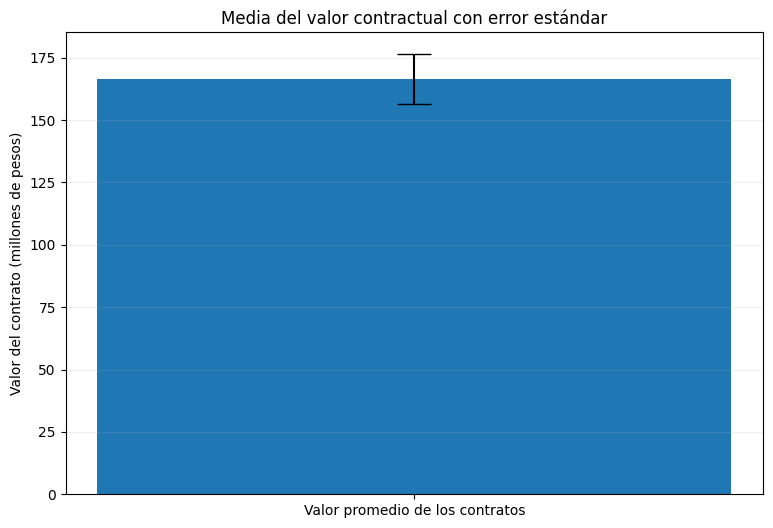

In [88]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de los contratos
contract_value = df["valor_del_contrato"].dropna()

# Estadísticos
media = contract_value.mean()
desviacion_estandar = contract_value.std()
n = len(contract_value)

# Error estándar de la media
error_estandar = desviacion_estandar / np.sqrt(n)

print("=" * 60)
print("ERROR ESTÁNDAR DE LA MEDIA")
print("=" * 60)
print(f"Número de contratos: {n:,}")
print(f"Media: ${media:,.0f}")
print(f"Desviación estándar: ${desviacion_estandar:,.0f}")
print(f"Error estándar: ${error_estandar:,.0f}")

# Gráfica de barras con error estándar
plt.figure(figsize=(9, 6))

plt.bar(
    ["Valor promedio de los contratos"],
    [media / 1_000_000],
    yerr=[error_estandar / 1_000_000],
    capsize=12
)

plt.ylabel("Valor del contrato (millones de pesos)")
plt.title("Media del valor contractual con error estándar")

plt.grid(axis="y", alpha=0.2)

plt.show()

La gráfica muestra una media contractual de aproximadamente $166,45 millones y un error estándar de $9,90 millones. Esto indica que la media está estimada con una variación relativamente pequeña respecto a su valor. Sin embargo, debido a la presencia de valores extremos y a la diferencia entre la media y la mediana, la media debe interpretarse con precaución y la mediana continúa siendo una medida más representativa del valor típico de los contratos.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos para las tres tarjetas de la plantilla. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

La conclusión debe referirse a asociación y a registros de adición. No debe presentarse como una predicción del futuro ni como evidencia causal.

**Identificadores de evidencia disponibles en esta versión ampliada del notebook:**

- E1 — descripción de `valor_del_contrato` (media, mediana, percentiles, histograma).
- E2 — vinculación de contratos y adiciones mediante `id_contrato`.
- E3 — comparación de valor y duración entre contratos con y sin registro de adición.
- E4 — validación externa con la población actual de Atlántico (datos.gov.co): compara la tasa de adición del recorte contra `Dias adicionados` en 63.133 contratos vigentes.
- E5 — EDA multivariado (crosstab, V de Cramér, estratificación por modalidad) sobre la asociación entre modalidad y `tuvo_adicion`.
- E6 — contratos con valor $0 (concentración por entidad, duración comparada) y error estándar de la media del valor contractual.

El equipo puede construir sus tres tarjetas con cualquier combinación de E1–E5; no es obligatorio usar los cinco. Si se reemplaza un hallazgo original por uno de E4 o E5, indíquelo explícitamente en la tarjeta.


## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: las diferencias observadas pueden deberse a que ciertos tipos de contrato o modalidades son, al mismo tiempo, más costosos y más propensos a recibir adiciones.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?
R/T Pone en duda que la relación entre tener un registro de adición y presentar valor y duración mayores (hallazgo E3) se deba al hecho mismo de tener adición, y no a que esos contratos pertenecen a modalidades o rangos de valor particulares que, de todas formas, tienden a ser más costosos o más largos.

2. ¿Qué tercera variable podría explicar parte de la asociación?
R/T La modalidad de contratación y el rango de valor del contrato. Ambas podrían estar relacionadas al mismo tiempo con el valor y la duración del contrato y con la probabilidad de que aparezca un registro en la base de adiciones, sin que exista una relación directa entre valor/duración y adición.

3. ¿Qué comparación ayudaría a comprobarlo?
R/T Comparar la tasa de adición dentro de cada grupo de valor (cuartiles) y dentro de cada modalidad, en lugar de comparar el conjunto completo sin distinguir esos grupos. Eso es justamente lo que hace la celda de código siguiente.



In [89]:
if "valor_del_contrato" in df.columns:
    valid_value = df["valor_del_contrato"].notna()
    by_value = df.loc[valid_value].copy()

    by_value["grupo_valor"] = pd.qcut(
        by_value["valor_del_contrato"],
        q=4,
        duplicates="drop",
    )

    addition_rate_by_value = (
        by_value.groupby("grupo_valor", observed=True)["tuvo_adicion"]
                .agg(["count", "mean"])
    )

    addition_rate_by_value["porcentaje_con_adicion"] = (
        addition_rate_by_value["mean"] * 100
    ).round(1)

    print("Frecuencia de adiciones por grupo de valor:")
    display(
        addition_rate_by_value[
            ["count", "porcentaje_con_adicion"]
        ]
    )

if "modalidad_de_contratacion" in df.columns:
    addition_rate_by_mode = (
        df.groupby("modalidad_de_contratacion")["tuvo_adicion"]
          .agg(["count", "mean"])
    )

    addition_rate_by_mode["porcentaje_con_adicion"] = (
        addition_rate_by_mode["mean"] * 100
    ).round(1)

    print("Modalidades con mayor número de contratos:")
    display(
        addition_rate_by_mode
        .sort_values("count", ascending=False)
        .head(10)[["count", "porcentaje_con_adicion"]]
    )


Frecuencia de adiciones por grupo de valor:


,count,porcentaje_con_adicion
grupo_valor,,
"(-0.001, 8183000.0]",12954,0.0
"(8183000.0, 17500000.0]",12160,0.1
"(17500000.0, 36300000.0]",12400,0.2
"(36300000.0, 172969667789.0]",12486,0.3


Modalidades con mayor número de contratos:


,count,porcentaje_con_adicion
modalidad_de_contratacion,,
Contratación directa,42208,0.2
Contratación régimen especial,5348,0.0
Mínima cuantía,1385,0.0
Selección Abreviada de Menor Cuantía,327,0.3
Contratación régimen especial (con ofertas),280,0.0
Selección abreviada subasta inversa,160,0.0
Contratación Directa (con ofertas),106,0.0
Licitación pública,82,1.2
Licitación pública Obra Publica,58,0.0


### Deténgase y revise

1. ¿La frecuencia de adiciones cambia entre grupos de valor?
R/T Sí, aumenta de forma gradual con el valor: 0,0 % en el cuartil más bajo, 0,1 % en el segundo, 0,2 % en el tercero y 0,3 % en el cuartil más alto. La diferencia es pequeña en términos absolutos, pero la dirección es consistente con el hallazgo E3 (los contratos con adición tienden a tener mayor valor).

2. ¿La modalidad parece modificar la comparación?
R/T Contratación directa concentra 42.208 de los 50.000 contratos (84,4 %) con una tasa de adición de 0,2 %; Licitación pública, con apenas 82 contratos, muestra 1,2 % (un solo contrato). La V de Cramér calculada en la sección E5 es de 0,017, muy por debajo del umbral de 0,10 fijado en el criterio previo, y la prueba chi-cuadrado da p = 0,23. Esto sugiere que, aunque hay diferencias nominales entre modalidades, no hay evidencia estadística sólida de que la modalidad por sí sola cambie sustancialmente la tasa de adición, sobre todo porque varias modalidades tienen muy pocos contratos.

3. ¿El hallazgo inicial se mantiene, se debilita o cambia?
R/T Se mantiene, aunque de forma más matizada. La diferencia de valor entre contratos con y sin adición (hallazgo E3) sigue presente incluso dentro de la modalidad más grande: en Contratación directa la mediana es de $36,5 millones con adición frente a $16,1 millones sin adición. Sin embargo, el número de casos con adición sigue siendo muy pequeño (70 en total, 66 de ellos en Contratación directa), por lo que la evidencia se debilita en el sentido de que ya no puede atribuirse únicamente al valor o a la modalidad de forma aislada; conviven varios factores.

4. ¿Qué conclusión todavía sería excesiva con estos datos?
R/T Sería excesivo afirmar que el valor del contrato o la modalidad "causan" la aparición de un registro de adición, o que la tasa de adición del recorte (0,14 %) representa la tasa real de adiciones en SECOP. La validación externa (E4) ya mostró que la tasa poblacional actual en Atlántico es de 16,3 %, más de cien veces mayor, lo que sugiere problemas de cobertura temporal en el cruce entre archivos más que un patrón real tan bajo.



## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?
R/T El tipo de entidad contratante o el objeto del contrato podrían influir tanto en el valor y la duración del contrato como en la probabilidad de que se registre una adición, sin que exista una relación directa entre valor y adición.

2. ¿Por qué podría modificar la interpretación?
R/T Si cierto tipo de entidad (por ejemplo, las que manejan contratos de mayor cuantía o duración) tiende también a generar más registros en la base de adiciones por razones administrativas propias —y no por el valor del contrato en sí—, la asociación observada entre valor/duración y tuvo_adicion sería producto de esa tercera variable y no de una relación directa entre ellas.

3. ¿Qué información adicional sería necesaria para comprobarlo?
R/T Sería necesario contar con el tipo de entidad, el sector y el objeto contractual de cada uno de los 70 contratos con adición, y compararlos con la distribución de esas mismas variables en el resto del recorte, para verificar si los contratos con adición están sobrerrepresentados en algún tipo de entidad en particular.



## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?
R/T Grupo A: contratos asignados aleatoriamente a la modalidad de contratación directa. Grupo B: contratos de valor y objeto contractual similares asignados aleatoriamente a otra modalidad (por ejemplo, licitación pública), manteniendo fijas las demás condiciones iniciales.

2. ¿Qué resultado mediría?
R/T Si el contrato recibió al menos un registro de adición dentro de un periodo fijo de seguimiento (o, de forma más precisa, la proporción del valor adicionado sobre el valor inicial).

3. ¿Sería viable asignar los grupos al azar?
R/T No. No es viable ni ético: la modalidad de contratación está determinada por la ley según el tipo y la cuantía del contrato, no puede asignarse de forma arbitraria a un contrato público real.

4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?
R/T Comparar contratos de valor y objeto similar que, por las reglas de cuantía, quedaron en distinta modalidad casi por azar (emparejamiento o *matching* por valor, sector y entidad), o aprovechar los umbrales legales de cuantía que definen la modalidad exigida para un diseño de regresión discontinua alrededor de esos umbrales.



### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [90]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


alpha                              0.05
potencia_objetivo                  0.80
tamaño_de_efecto_estandarizado     0.50
n_aproximado_por_grupo            63.00
dtype: float64

### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?
R/T Se necesitarían más observaciones. La calculadora de potencia muestra que, para un efecto grande (d = 0,8), bastan cerca de 26 contratos por grupo, mientras que para un efecto pequeño (d = 0,2) se requieren cerca de 393, y para un efecto sutil (d = 0,1) casi 1.571. Cuanto más pequeña es la diferencia que se quiere detectar, mayor es la muestra necesaria.

2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?
R/T Tener 50.000 contratos ayuda a estimar una diferencia con precisión, pero no corrige el problema si esa diferencia está contaminada por una tercera variable. En este expediente, el grupo con adición es de apenas 70 contratos frente a 49.930 sin adición: aunque el total del recorte es grande, el grupo relevante para comparar es minúsculo, y ningún aumento del total soluciona esa asimetría ni el hecho de que la modalidad o el tipo de entidad puedan estar detrás de la asociación observada.

3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?
R/T La limitación más importante es el tamaño extremadamente pequeño y probablemente sesgado del grupo con registro de adición (70 de 50.000, 0,14 %), sumado a la discrepancia con la tasa poblacional actual de Atlántico (16,3 %, hallazgo E4). Esto indica que el cruce entre secop_recorte.csv y secop_adiciones.csv probablemente no captura todas las adiciones reales, por lo que cualquier comparación basada en tuvo_adicion debe leerse como una asociación dentro de un subconjunto reducido y no representativo, y no como una medición confiable de la tasa real de adiciones en SECOP.



# **T-test**

Hipótesis: H0 dice que la media de la variable es igual en ambos grupos, y H1 que es distinta (dos colas, α = 0,05).
Welch, no el t clásico. Los tamaños son 70 contra ~49.930 y las varianzas seguramente muy distintas, así que no se puede asumir varianzas iguales.
Escala logarítmica. El valor tiene cola extrema (máximo de $173.000 M). Un t-test sobre pesos crudos compara medias dominadas por unos pocos contratos. Con log, la diferencia se lee como razón de medias geométricas. Lo mismo aplica a la duración, que también es asimétrica.
Solo valores positivos. Se excluyen los 175 ceros y las 599 duraciones no utilizables, porque el log no admite ceros.
Prueba de robustez. Mann-Whitney no depende de la normalidad y sirve de contraste.


In [91]:
from scipy import stats
import numpy as np
import pandas as pd

def welch_log(df, col, etiqueta):
    d = df[df[col].notna() & (df[col] > 0)]
    sin = np.log(d.loc[~d["tuvo_adicion"], col])
    con = np.log(d.loc[d["tuvo_adicion"], col])

    # Welch
    t, p = stats.ttest_ind(con, sin, equal_var=False)
    n1, n2 = len(con), len(sin)
    v1, v2 = con.var(ddof=1), sin.var(ddof=1)
    se = np.sqrt(v1/n1 + v2/n2)
    gl = se**4 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    dif = con.mean() - sin.mean()
    tcrit = stats.t.ppf(0.975, gl)
    ic = (dif - tcrit*se, dif + tcrit*se)

    # Tamaño de efecto (d de Cohen con desviación combinada)
    sp = np.sqrt(((n1-1)*v1 + (n2-1)*v2) / (n1+n2-2))
    d_cohen = dif / sp

    # Robustez
    u, p_mw = stats.mannwhitneyu(con, sin, alternative="two-sided")

    return pd.Series({
        "n con adición": n1,
        "n sin adición": n2,
        "media log (con)": con.mean(),
        "media log (sin)": sin.mean(),
        "razón medias geométricas": np.exp(dif),
        "IC95% razón": f"{np.exp(ic[0]):.2f} – {np.exp(ic[1]):.2f}",
        "t de Welch": t,
        "gl (Welch)": gl,
        "p (Welch)": p,
        "d de Cohen (log)": d_cohen,
        "p (Mann-Whitney)": p_mw,
    }, name=etiqueta)

resultados = pd.concat([
    welch_log(df, "duracion_dias", "duración (días)"),
    welch_log(df, "valor_del_contrato", "valor del contrato"),
], axis=1)

display(resultados)

,duración (días),valor del contrato
n con adición,70,70
n sin adición,49331,49755
media log (con),5.352929,17.799999
media log (sin),4.728217,16.790784
razón medias geométricas,1.867709,2.743445
IC95% razón,1.66 – 2.10,1.88 – 4.01
t de Welch,10.553943,5.292103
gl (Welch),69.631311,69.139928
p (Welch),0.0,0.000001
d de Cohen (log),0.705285,0.745437


In [92]:
import numpy as np
import pandas as pd
from scipy import stats

def formato_p(p):
    return "menor que 0.001" if p < 0.001 else f"{p:.3f}"

def comparar(df, columna, nombre, unidad, divisor=1):
    # Solo valores positivos (sin ceros ni duraciones inválidas)
    d = df[df[columna].notna() & (df[columna] > 0)]
    con = d.loc[d["tuvo_adicion"], columna] / divisor
    sin = d.loc[~d["tuvo_adicion"], columna] / divisor

    # Prueba t de Welch, en unidades originales
    t, p = stats.ttest_ind(con, sin, equal_var=False)
    diferencia = con.mean() - sin.mean()
    se = np.sqrt(con.var(ddof=1) / len(con) + sin.var(ddof=1) / len(sin))
    ic_bajo, ic_alto = diferencia - 1.96 * se, diferencia + 1.96 * se

    # Diferencia de medianas con intervalo por remuestreo (bootstrap)
    rng = np.random.default_rng(42)
    dif_medianas = []
    for _ in range(2000):
        m_con = np.median(rng.choice(con.values, len(con), replace=True))
        m_sin = np.median(rng.choice(sin.values, len(sin), replace=True))
        dif_medianas.append(m_con - m_sin)
    med_bajo, med_alto = np.percentile(dif_medianas, [2.5, 97.5])

    print("=" * 62)
    print(nombre.upper())
    print("=" * 62)
    print(f"Contratos con adición: {len(con):,} | sin adición: {len(sin):,}")
    print()
    print(f"Promedio con adición:   {con.mean():>14,.1f} {unidad}")
    print(f"Promedio sin adición:   {sin.mean():>14,.1f} {unidad}")
    print(f"Mediana con adición:    {con.median():>14,.1f} {unidad}")
    print(f"Mediana sin adición:    {sin.median():>14,.1f} {unidad}")
    print()
    print(f"Diferencia de promedios: {diferencia:,.1f} {unidad}")
    print(f"  Intervalo 95%: de {ic_bajo:,.1f} a {ic_alto:,.1f}")
    print(f"Diferencia de medianas:  {con.median() - sin.median():,.1f} {unidad}")
    print(f"  Intervalo 95% (bootstrap): de {med_bajo:,.1f} a {med_alto:,.1f}")
    print()
    print(f"t de Welch: {t:.2f}   |   p: {formato_p(p)}")
    if p < 0.05:
        print("Lectura: la diferencia es poco probable por azar.")
    else:
        print("Lectura: no hay evidencia suficiente de diferencia.")
    print()

# Chequeo rápido de los datos
print("Filas en df:", f"{len(df):,}")
print("IDs repetidos:", int(df["id_contrato"].duplicated().sum()))
print()

comparar(df, "duracion_dias", "Duración del contrato", "días")
comparar(df, "valor_del_contrato", "Valor del contrato", "millones de pesos", divisor=1_000_000)

Filas en df: 50,000
IDs repetidos: 0

DURACIÓN DEL CONTRATO
Contratos con adición: 70 | sin adición: 49,331

Promedio con adición:            232.3 días
Promedio sin adición:            155.8 días
Mediana con adición:             268.5 días
Mediana sin adición:             120.0 días

Diferencia de promedios: 76.5 días
  Intervalo 95%: de 56.6 a 96.3
Diferencia de medianas:  148.5 días
  Intervalo 95% (bootstrap): de 101.5 a 169.0

t de Welch: 7.56   |   p: menor que 0.001
Lectura: la diferencia es poco probable por azar.

VALOR DEL CONTRATO
Contratos con adición: 70 | sin adición: 49,755

Promedio con adición:            339.1 millones de pesos
Promedio sin adición:            166.8 millones de pesos
Mediana con adición:              38.0 millones de pesos
Mediana sin adición:              17.5 millones de pesos

Diferencia de promedios: 172.3 millones de pesos
  Intervalo 95%: de -38.3 a 383.0
Diferencia de medianas:  20.5 millones de pesos
  Intervalo 95% (bootstrap): de 10.3 a 26.3

El promedio de valor se ve arrastrado por unos pocos contratos gigantes. Por eso el código muestra también las medianas, que representan mejor al contrato típico.
La diferencia de medianas trae su propio intervalo. Si el intervalo no incluye 0, la diferencia es real dentro de estos datos.
Sirve para entender y explicar las cifras. Para reportar el test formal, la versión con logaritmos sigue siendo la más confiable, porque el valor tiene cola muy larga.

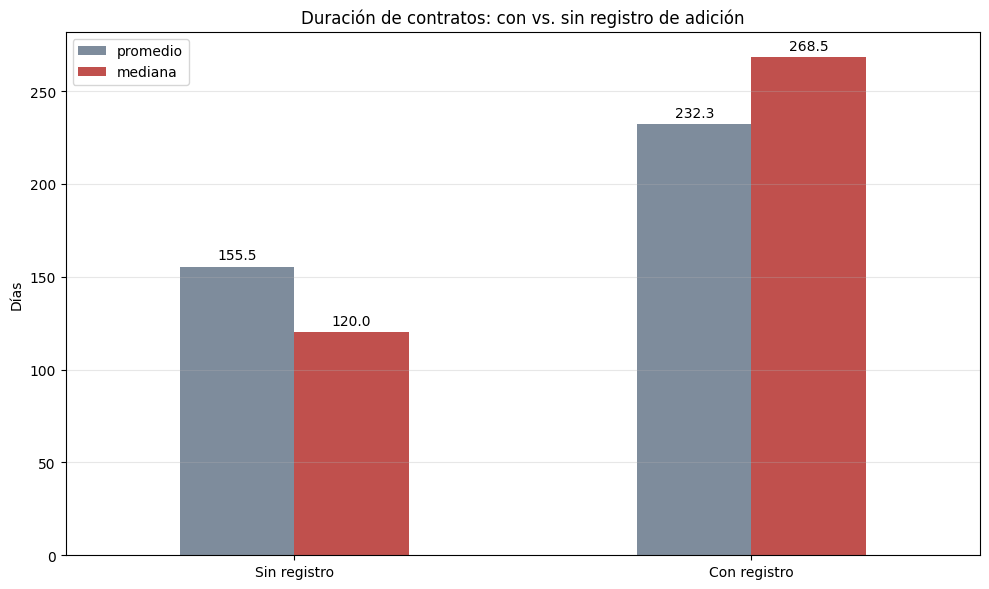

In [99]:
import matplotlib.pyplot as plt

# Colores de la gráfica de referencia
colores = ["#7E8C9C", "#C0504D"]

duracion = df.groupby("tuvo_adicion")["duracion_dias"].agg(
    promedio="mean",
    mediana="median"
).rename(index={
    False: "Sin registro",
    True: "Con registro"
})

ax = duracion[["promedio", "mediana"]].plot(
    kind="bar",
    figsize=(10,6),
    color=colores,
    title="Duración de contratos: con vs. sin registro de adición"
)

plt.ylabel("Días")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

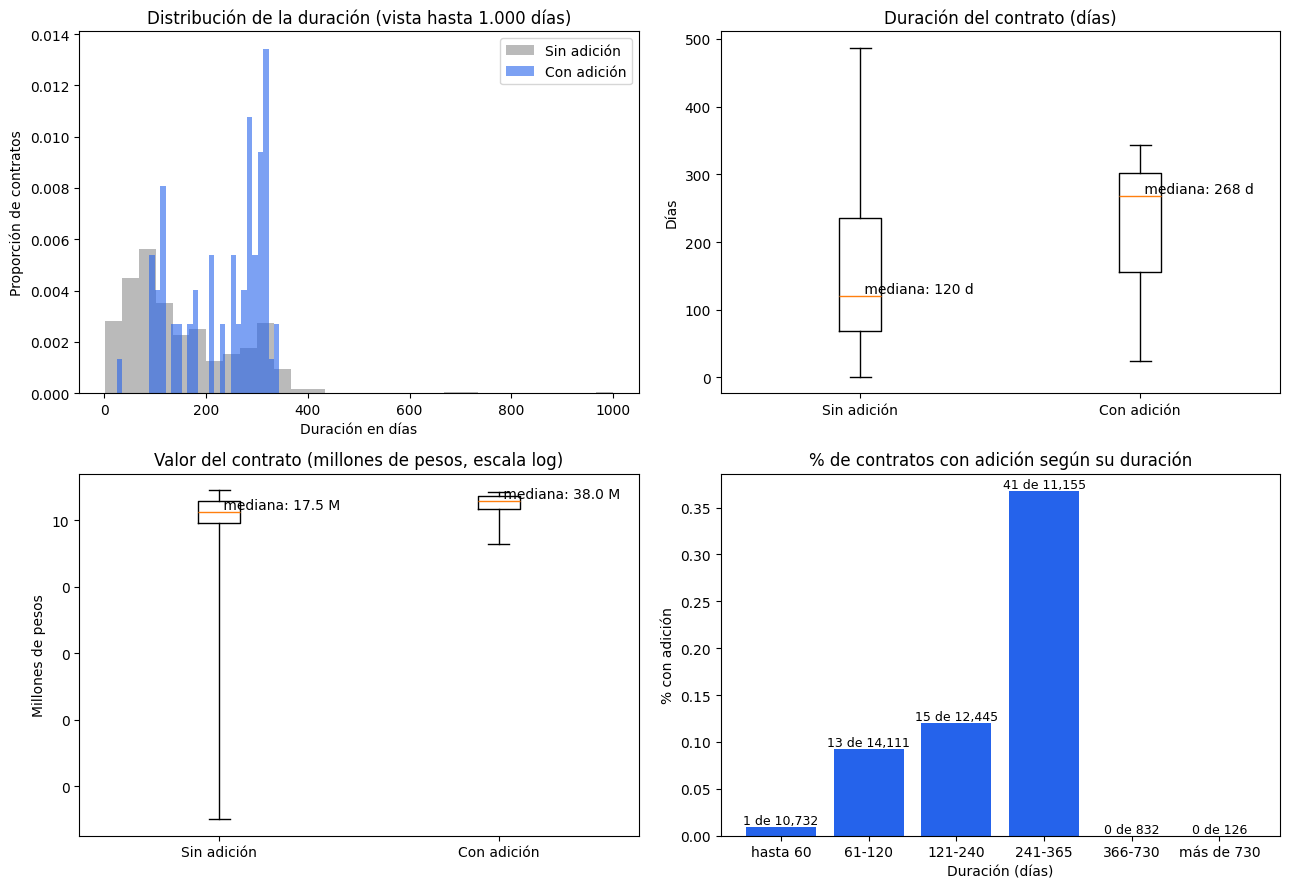

,con adición,total,% con adición
duracion_dias,,,
hasta 60,1,10732,0.009318
61-120,13,14111,0.092127
121-240,15,12445,0.120530
241-365,41,11155,0.367548
366-730,0,832,0.000000
más de 730,0,126,0.000000


In [93]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")
etiquetas = ["Sin adición", "Con adición"]
colores = ["#8c8c8c", "#2563eb"]

d = df[df["duracion_dias"] > 0].copy()
v = df[df["valor_del_contrato"] > 0].copy()

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1) Histograma de duración (proporción, para poder comparar grupos de tamaños distintos)
tope = 1000
for flag, etiqueta, color in [(False, etiquetas[0], colores[0]), (True, etiquetas[1], colores[1])]:
    datos = d.loc[d["tuvo_adicion"] == flag, "duracion_dias"].clip(upper=tope)
    ax[0, 0].hist(datos, bins=30, density=True, alpha=0.6, label=etiqueta, color=color)
ax[0, 0].set_title("Distribución de la duración (vista hasta 1.000 días)")
ax[0, 0].set_xlabel("Duración en días")
ax[0, 0].set_ylabel("Proporción de contratos")
ax[0, 0].legend()

# 2) Boxplot de duración
datos_box = [d.loc[~d["tuvo_adicion"], "duracion_dias"], d.loc[d["tuvo_adicion"], "duracion_dias"]]
ax[0, 1].boxplot(datos_box, showfliers=False)
ax[0, 1].set_xticks([1, 2])
ax[0, 1].set_xticklabels(etiquetas)
for i, dato in enumerate(datos_box, start=1):
    ax[0, 1].text(i, dato.median(), f" mediana: {dato.median():,.0f} d", va="bottom")
ax[0, 1].set_title("Duración del contrato (días)")
ax[0, 1].set_ylabel("Días")

# 3) Boxplot de valor en escala logarítmica, con números normales
valor_box = [
    v.loc[~v["tuvo_adicion"], "valor_del_contrato"] / 1e6,
    v.loc[v["tuvo_adicion"], "valor_del_contrato"] / 1e6,
]
ax[1, 0].boxplot(valor_box, showfliers=False)
ax[1, 0].set_yscale("log")
ax[1, 0].yaxis.set_major_formatter(fmt)
ax[1, 0].set_xticks([1, 2])
ax[1, 0].set_xticklabels(etiquetas)
for i, dato in enumerate(valor_box, start=1):
    ax[1, 0].text(i, dato.median(), f" mediana: {dato.median():,.1f} M", va="bottom")
ax[1, 0].set_title("Valor del contrato (millones de pesos, escala log)")
ax[1, 0].set_ylabel("Millones de pesos")

# 4) Porcentaje de contratos con adición según rango de duración
rangos = pd.cut(
    d["duracion_dias"],
    bins=[0, 60, 120, 240, 365, 730, np.inf],
    labels=["hasta 60", "61-120", "121-240", "241-365", "366-730", "más de 730"],
)
tabla = d.groupby(rangos, observed=True)["tuvo_adicion"].agg(["sum", "count", "mean"])
tabla["pct"] = tabla["mean"] * 100
barras = ax[1, 1].bar(tabla.index.astype(str), tabla["pct"], color="#2563eb")
for barra, (_, fila) in zip(barras, tabla.iterrows()):
    ax[1, 1].text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{int(fila['sum'])} de {int(fila['count']):,}",
        ha="center", va="bottom", fontsize=9,
    )
ax[1, 1].set_title("% de contratos con adición según su duración")
ax[1, 1].set_xlabel("Duración (días)")
ax[1, 1].set_ylabel("% con adición")

plt.tight_layout()
plt.show()

display(tabla.rename(columns={"sum": "con adición", "count": "total", "pct": "% con adición"})[["con adición", "total", "% con adición"]])

**Gráfico 1: distribución de la duración (arriba a la izquierda)**

Cada barra muestra qué tan común es una duración. Los contratos sin adición (gris) se concentran en duraciones cortas, sobre todo entre 30 y 200 días, y algunos llegan hasta unos 400. Los contratos con adición (azul) se ubican más a la derecha: la mayoría está entre 250 y 330 días, es decir, entre 8 y 11 meses.

Las barras azules son irregulares y con picos porque solo son 71 contratos. Conviene no leer barra por barra, sino el patrón general: el grupo azul está desplazado hacia los contratos de casi un año.


**Gráfico 2: caja de duración (arriba a la derecha)**

La caja contiene a la mitad de los contratos de cada grupo, y la línea naranja marca el contrato del medio.

Sin adición: el contrato típico dura 120 días (4 meses). La mitad de los contratos está entre 70 y 235 días.
Con adición: el contrato típico dura 271 días (9 meses). La mitad está entre 160 y 300 días.

Dos cosas llaman la atención. La caja azul es más angosta, así que estos contratos se parecen bastante entre sí, y su límite superior está cerca de los 340 días, por debajo del de los contratos sin adición. Los contratos con adición son largos, pero no los más largos de todos. Los puntos extremos están ocultos en este gráfico.

**Gráfico 3: valor del contrato (abajo a la izquierda)**

Este gráfico salió con un problema de presentación en el eje vertical muestra "10, 0, 0, 0, 0", así que no sirve para leer valores. Pero podemos analizarlo de acuerdo a las medianas escritas: 17,5 millones sin adición y 39,1 millones con adición, unas 2,2 veces más.

Lo que sí se aprecia es que la caja azul está más arriba y es más compacta, es decir, los contratos con adición son más caros y más parejos entre sí. Además, la línea larga hacia abajo en "sin adición" indica que hay contratos con valores minúsculos, muy por debajo de un millón, que probablemente son errores de registro.

**Gráfico 4 y tabla: % con adición según la duración (abajo a la derecha)**

Es el más informativo. La tabla dice cuántos contratos con adición hay en cada tramo:
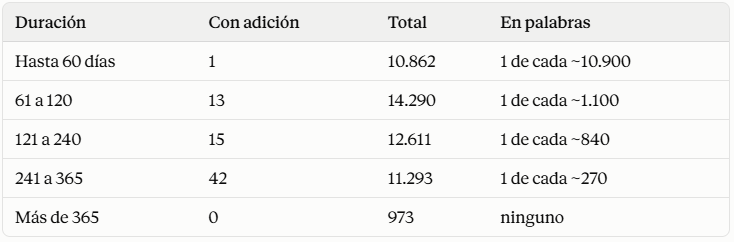

La tasa sube de forma muy clara: los contratos de 8 a 12 meses tienen unas 40 veces más adiciones que los de dos meses o menos. Además, el 59 % de todos los contratos con adición (42 de 71) está en ese tramo, que solo reúne al 23 % de los contratos.

Después de un año, la tasa cae a cero. Ojo con esto: son solo 973 contratos, así que ver cero casos podría ser casualidad y no una regla. Aun así, es curioso que la tasa no siga subiendo con la duración.

**POR ENDE**

Los contratos con adición duran más (mediana de 120 a 270 días) y cuestan más (17,5 a 39 millones). La prueba estadística lo confirmó con una diferencia grande. La duda era por qué.

Lo que aportan los gráficos.

Más tiempo, más oportunidad de adición, pero solo hasta cerca de un año. La tasa crece con la duración hasta el tramo de 8 a 12 meses. Eso respalda la explicación de "tiempo de exposición": un contrato corto termina antes de necesitar cambios.
La adición se concentra en contratos que cubren casi todo un año. Es una pista, no una prueba. Puede tener que ver con contratos firmados al inicio de la vigencia que se ajustan hacia fin de año. Faltaría mirar el mes de firma, que estaba en el criterio previo del notebook y nunca se analizó.
El valor sigue a la duración. Los contratos largos cuestan más en total, y ya vimos que además su valor por mes es algo mayor.

# **Conclusión general del Expediente D**
# **La pregunta**

Se busca saber si ciertas características de un contrato público (valor, duración, modalidad) se asocian con que después tenga un registro de adición. Es una pregunta de asociación, no de causa.

# **Qué mostraron los datos**

1. Los contratos son muy desiguales en valor. El contrato típico cuesta unos 17,5 millones, pero el promedio (166 millones) lo arrastran unos pocos contratos gigantes, con un máximo de casi 173.000 millones. Por eso el análisis se apoya en medianas y no en promedios.

2. La calidad de los datos es aceptable, con matices. No hay IDs repetidos ni faltantes en lo esencial. Sí hay unos 175 contratos con valor $0, que en su mayoría son comodatos, arrendamientos y convenios sin desembolso (no parecen errores), y cerca de 600 contratos con duración faltante o inválida.

3. El cruce con el archivo de adiciones es el punto más débil. Solo unos 70 contratos (0,14 %) tienen algún registro de adición. La población actual de Atlántico muestra una señal de prórroga del 16 %, unas cien veces mayor. Esa brecha no significa que casi ningún contrato reciba adiciones. Lo más probable es que el archivo de adiciones esté incompleto o no coincida bien con el recorte.

4. Los contratos con adición son más largos y más caros. La duración típica pasa de unos 120 días a unos 270, y el valor de 17,5 a unos 39 millones. Las pruebas estadísticas confirman que no es casualidad: es una diferencia grande y estable, y se sostiene con dos métodos distintos.

5. La modalidad de contratación no explica el patrón. Casi todos los contratos con adición son de Contratación directa, pero esa modalidad también es el 84 % de todo el recorte. Con tan pocos casos en las demás modalidades, no se puede afirmar que alguna sea más propensa.

6. Los gráficos revelan el mecanismo más probable. La proporción de contratos con adición sube con la duración: casi nula en contratos de dos meses o menos y cerca de 40 veces mayor en los de 8 a 12 meses. Más de un año no muestra casos, pero son pocos contratos para sacar conclusiones.

## Por qué los contratos con adición duran más

La explicación más sólida es el tiempo de vigencia: un contrato largo tiene más oportunidades de necesitar un cambio que uno corto. El valor acompaña a la duración, porque en contratos por meses el costo total crece con los meses. Aun así, los contratos con adición también cuestan algo más por mes, así que la duración no lo explica todo.

Otras dos explicaciones no se pueden descartar con estos datos. Una es que la fecha de fin ya incluya la prórroga, con lo cual la duración sería en parte consecuencia de la adición. La otra es que influya el tipo de contrato: obra o consultoría suelen ser más largos y más propensos a modificaciones que una prestación de servicios simple.

## Lo que no se puede afirmar
* Que la duración o el valor causen una adición.
* Que la tasa de adición real sea de 0,14 %.
* Que el patrón valga para todos los contratos de Atlántico, porque el grupo con adición es muy pequeño y probablemente no es representativo.
* Que las diferencias por modalidad no existan, porque las pruebas hechas tienen muy poca fuerza con tantos grupos casi vacíos.

## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.
